#### **Human in Loop**

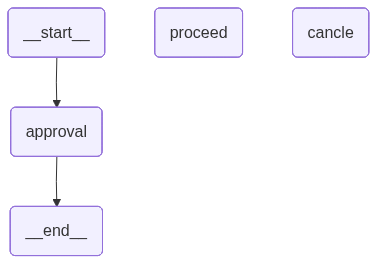

In [17]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt

from typing import TypedDict, Literal, Optional

class ApprovalState(TypedDict):
    approval_detail: str
    status: Optional[Literal['Approved', 'Pending', 'Rejected']]


def approval_node(state:ApprovalState):
    decision = interrupt({
        'question':'Approve this Action.',
        'details':state['approval_detail']
    })
    return Command(goto='proceed' if decision else 'cancle')


def proceed_node(state:ApprovalState):
    return {'status':'Approved'}


def cancle_node(state:ApprovalState):
    return {'status':'Rejected'}

graph = StateGraph(ApprovalState)

## Add Node
graph.add_node('proceed', proceed_node)
graph.add_node('cancle', cancle_node)
graph.add_node('approval', approval_node)

## Add Edge
graph.add_edge(START, 'approval')
graph.add_edge('cancle', END)
graph.add_edge('proceed', END)

checkpoint = MemorySaver()
final_graph = graph.compile(checkpointer=checkpoint)

from IPython.display import Image
Image(final_graph.get_graph().draw_mermaid_png())




In [21]:
config = {'configurable':{'thread_id':'approve-456'}}
inital=final_graph.invoke({
    'approval_detail':'approve the Summery',
    'status':'Pending'},
    config=config
)

print(inital['__interrupt__'])

[Interrupt(value={'question': 'Approve this Action.', 'details': 'approve the Summery'}, id='09666d10c8c9b4894a3c75d9f23b90af')]


In [22]:
resume = final_graph.invoke(Command(resume=True), config=config)
print(resume)

{'approval_detail': 'approve the Summery', 'status': 'Approved'}
